# MACH 00 · Sample overview

The nine MACH clusters in the HeCS-omnibus cluster sample: selection box in the N_spec–M200 plane (Figure 1), the cluster property table of the paper, and the number of DESI and NED redshifts in the MACH fields.

**Inputs** (not included in the repository)
- `DATA/MACH_PHOT/MACH_photcat_3R200.csv` – MACH photometric catalog with redshifts, within 3 R200
- `DATA/MACH_PHOT/AllHeCS_VAC_updated.csv` – HeCS-omnibus cluster catalog
- `../SMF/MACH_1dspec_limit.csv` – spectroscopic completeness limits from `02_MACH_1Dspec_completeness_analysis.ipynb`

**Output**: `FIGURE/IMAGES/Figure1.pdf`

In [21]:
# ============================================================================
# Setup
# ============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from astropy.cosmology import LambdaCDM

# Cosmology used throughout this project
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

# Matplotlib style shared by the notebooks of this repository
plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,
    'lines.linewidth': 2,
    'axes.linewidth': 4,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})

# Show every column when a DataFrame is displayed
pd.set_option('display.max_columns', None)

# The nine MACH clusters
MACHLIST = ['A2245', 'A1767', 'A2244', 'A1831', 'A2034', 'A7', 'A2255', 'A2029', 'A2065']

# Repository root, located relative to this notebook; DATA/ and FIGURE/ hang off it
MAINPATH = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
FIGUREPATH = f"{MAINPATH}/FIGURE/IMAGES"

%config InlineBackend.figure_format = 'retina'

In [22]:
# Define file paths
mach_file = f"{MAINPATH}/DATA/MACH_PHOT/MACH_photcat_3R200.csv"
hecs_vac_file = f"{MAINPATH}/DATA/MACH_PHOT/AllHeCS_VAC_updated.csv"

# Load datasets
mach_data = pd.read_csv(mach_file)
hecs_vac_data = pd.read_csv(hecs_vac_file)

# Apply extinction corrections
mach_data['cmodelMag_r_0'] = mach_data['cmodelMag_r'] - mach_data['extinction_r']
mach_data['cmodelMag_g_0'] = mach_data['cmodelMag_g'] - mach_data['extinction_g']

# Objects within 3 R200
df = mach_data.loc[mach_data['Rcl/R200'] <= 3.0].copy()

# 1. MACH clusters in the HeCS-omnibus sample (Figure 1)

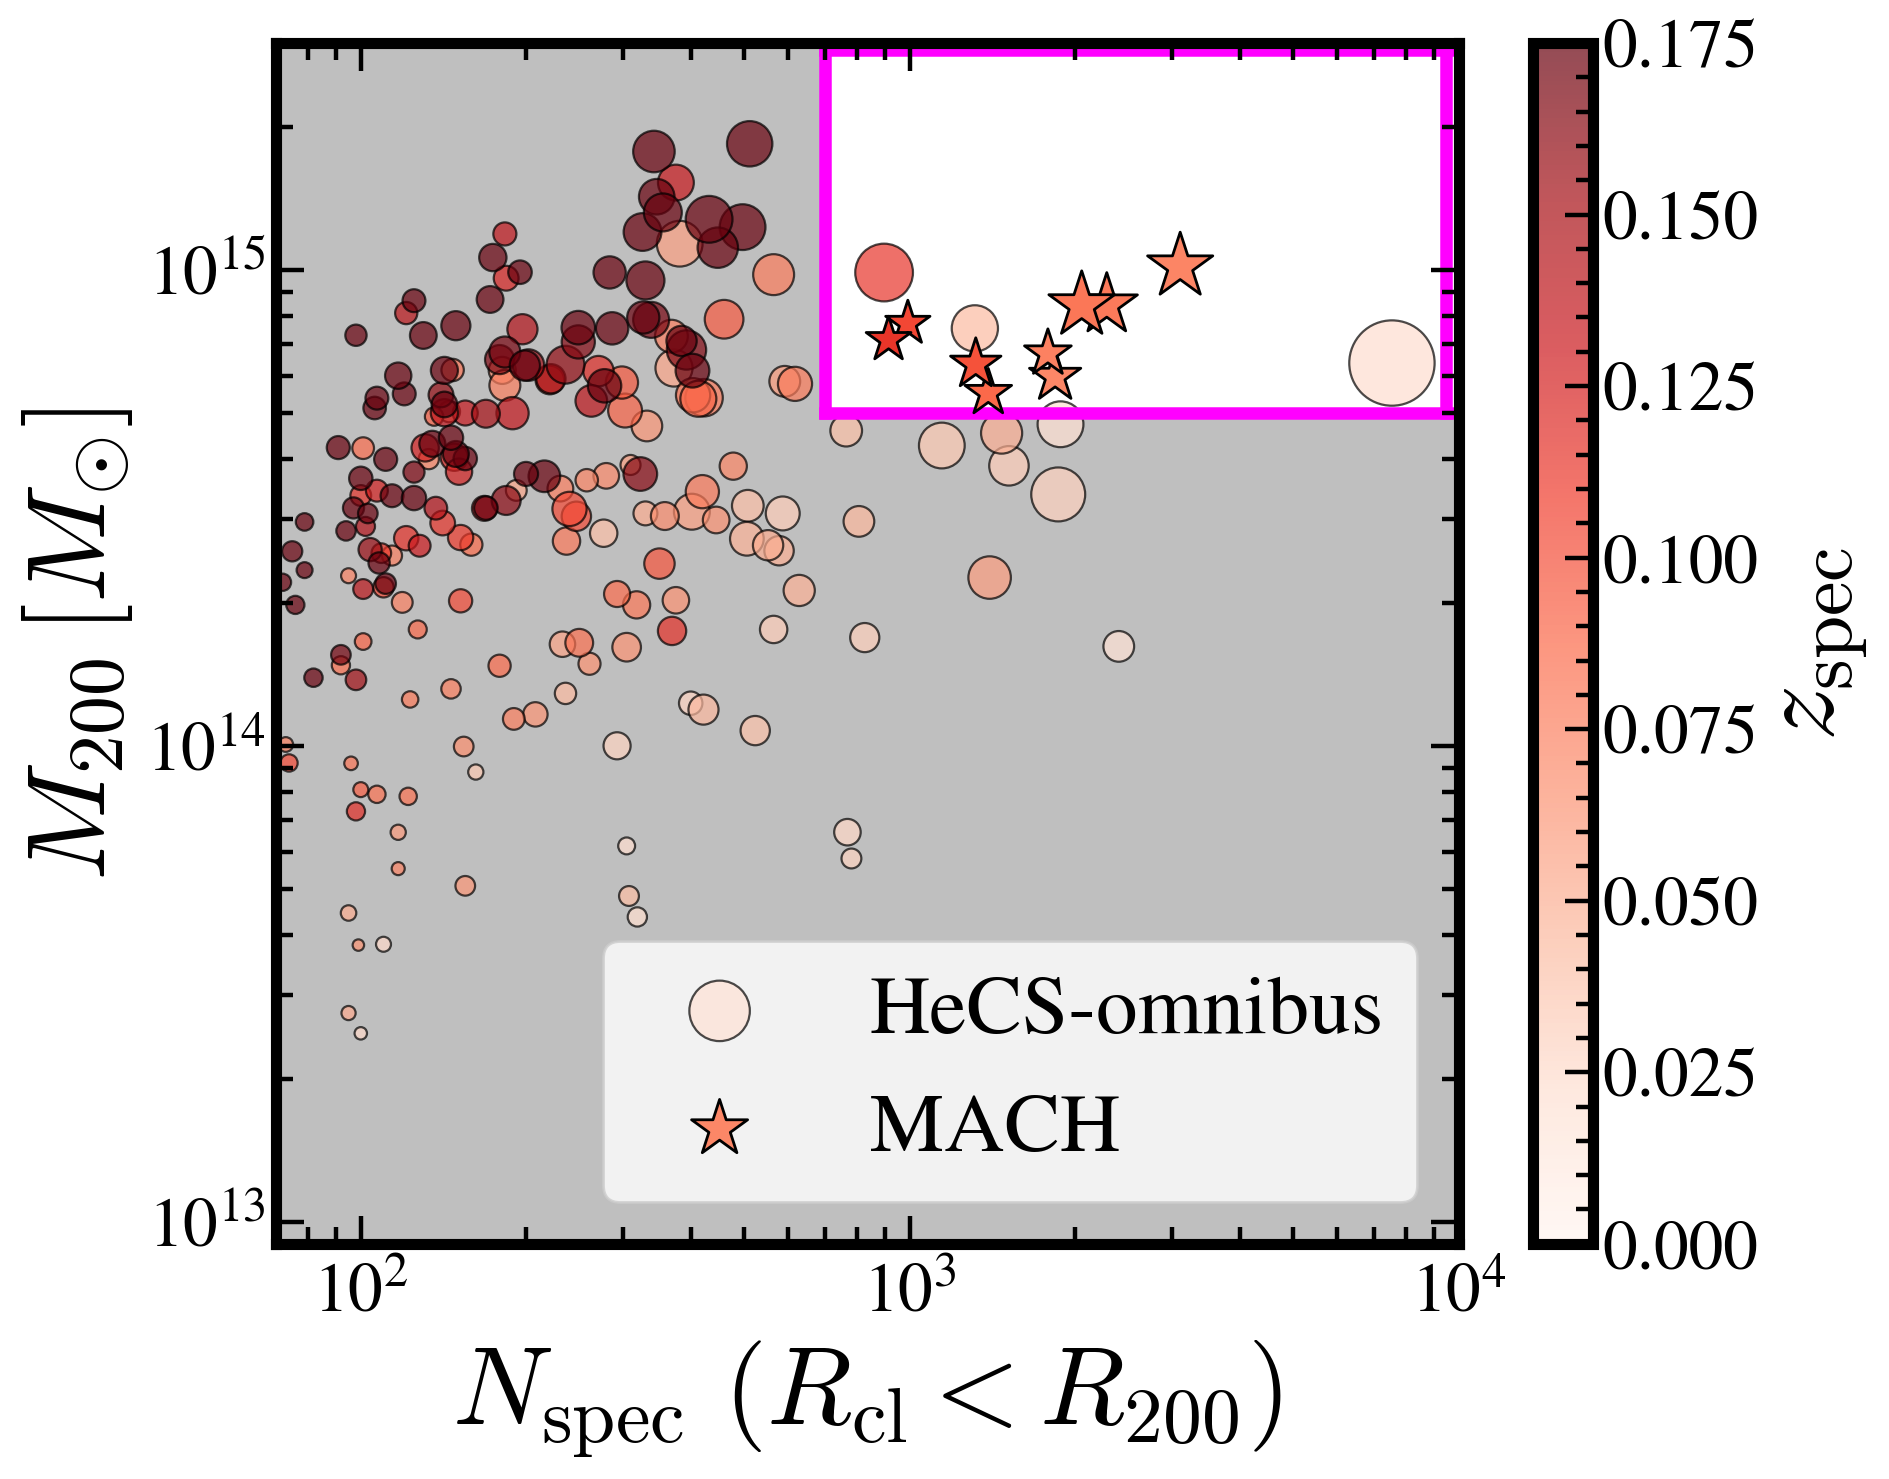

In [3]:
# --- Separate MACH (target) clusters and non-MACH (non-target) clusters ---

# Make a mask for MACH clusters
target_mask = hecs_vac_data['CLID'].isin(MACHLIST)

# Split the dataset into MACH clusters and others
target_data = hecs_vac_data[target_mask].copy()
non_target_data = hecs_vac_data[~target_mask].copy()

# Plot only: shift the A2029 symbol by +50 in N_spec so that it does not overlap with its neighbour
target_data.loc[target_data["CLID"] == "A2029", "NSPEC_R200"] += 50

# --- Plot setup ---

# Scaling factor for plot size
fs = 2
fig, ax = plt.subplots(figsize=(5 * fs, 4 * fs))

# Use the 'Reds' colormap to color points by redshift
cmap = plt.get_cmap('Reds')
# Normalize the colorbar to a redshift range covering all data
norm = plt.Normalize(0, 0.175)

# Control scatter marker sizes
scale_factor = 1.0

# --- Plot background and highlight region ---

# Fill the top and bottom rectangular backgrounds for highlighting, using gray
# Remove edge lines from the gray regions so they don't stick out past the magenta borders.
ax.fill_betweenx(
    [5e14, 1e16], x1=0, x2=700,
    color='gray', alpha=0.5, zorder=0,
    linewidth=0, edgecolor='none'   # no gray edge line
)      # left part
ax.fill_betweenx(
    [0, 5e14], x1=0, x2=10000,
    color='gray', alpha=0.5, zorder=0,
    linewidth=0, edgecolor='none'   # no gray edge line
)       # bottom part

# Draw thick magenta boundaries for a region of interest
ax.plot([700, 10000], [5e14, 5e14], color='magenta', linewidth=4.5, zorder=1)       # bottom border
ax.plot([700, 10000], [2.9e15, 2.9e15], color='magenta', linewidth=4.5, zorder=1)   # upper border
ax.plot([700, 700], [5e14, 3e15], color='magenta', linewidth=4.5, zorder=1)         # left border
ax.plot([9500, 9500], [5e14, 3e15], color='magenta', linewidth=4.5, zorder=1)       # right border

# --- Plot the clusters on the scatter plot ---

# Plot non-target clusters as circles
sc_non_target = ax.scatter(
    non_target_data['NSPEC_R200'],
    non_target_data['M200'],
    marker='o',
    linewidths=0.8,
    c=non_target_data['Z'],
    cmap=cmap,
    norm=norm,
    s=scale_factor * non_target_data['NMEM_R200'],
    edgecolor='black',
    alpha=0.7,
    label='HeCS-omnibus',
    zorder=0
)

# Plot target (MACH) clusters as stars
sc_target = ax.scatter(
    target_data['NSPEC_R200'],
    target_data['M200'],
    marker='*',
    c=target_data['Z'],
    cmap=cmap,
    norm=norm,
    s=scale_factor * target_data['NMEM_R200'],
    edgecolor='black',
    alpha=1.0,
    label='MACH',
    zorder=2
)

# --- Axes formatting ---

# Set y-axis to show logarithmic mass range
ax.set_yscale('log')
ax.set_ylim([9e12, 3e15])

# Set x-axis (number of spectra) to log scale and range
ax.set_xscale('log')
ax.set_xlim([70, 10000])

# Label axes with nice formatting for LaTeX-looking math
ax.set_xlabel(r'$N_\mathrm{spec}\,\, (R_\mathrm{cl}<R_{200})$', fontsize=40)
ax.set_ylabel(r'$M_{200}\,[M_{\odot}]$', fontsize=40)

# Put ticks also on the top and right, and point them inward
ax.tick_params(direction='in', which='both', top=True, right=True)

# Add legend for cluster types
ax.legend(loc='lower right', fontsize=30)

# --- Colorbar for the redshift ---

cbar = plt.colorbar(sc_non_target, ax=ax)
cbar.set_label(r'$z_\mathrm{spec}$', fontsize=40)

# --- Output the plot ---

plt.tight_layout()

plt.savefig(f"{MAINPATH}/FIGURE/IMAGES/Figure1.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [4]:
# The MACH clusters
mach_df = hecs_vac_data[
    hecs_vac_data['CLID'].isin(MACHLIST)
][['CLID', 'Z', 'NMEM_R200', 'NSPEC_R200', 'R200', 'M200']].sort_values(by='M200', ascending=False)
print("# MACH information")
print(mach_df, "\n")

# Clusters inside the selection box (N_spec > 700, M200 > 5e14) that are not in MACHLIST
almost_mach_df = hecs_vac_data[
    (hecs_vac_data['NSPEC_R200'] > 700) &
    (hecs_vac_data['M200'] > 5e14) &
    (~hecs_vac_data['CLID'].isin(MACHLIST))
][['CLID', 'Z', 'NMEM_R200', 'NSPEC_R200', 'R200', 'M200']].sort_values(by='M200', ascending=False)
print("# Almost-MACH but not MACH information")
print(almost_mach_df, "\n")

# MACH information
      CLID         Z  NMEM_R200  NSPEC_R200  R200          M200
64   A2065  0.073124        609      3109.0  2.03  1.017801e+15
77   A2029  0.078745        538      2235.0  1.90  8.453550e+14
83   A2255  0.080140        618      2057.0  1.90  8.430537e+14
113     A7  0.103245        281       992.0  1.83  7.723876e+14
120  A2034  0.113194        287       915.0  1.78  7.137963e+14
68   A1831  0.075042        313      1785.0  1.76  6.681556e+14
109  A2244  0.098670        364      1319.0  1.72  6.339830e+14
60   A1767  0.071220        377      1840.0  1.70  5.973904e+14
95   A2245  0.088030        312      1390.0  1.65  5.519038e+14 

# Almost-MACH but not MACH information
      CLID         Z  NMEM_R200  NSPEC_R200  R200          M200
121  A2069  0.113882        432       898.0  1.98  9.882829e+14
26    A119  0.044430        277      1314.0  1.85  7.543791e+14
4     Coma  0.023416        944      7557.0  1.76  6.378430e+14 



# 2. Cluster property table

In [5]:
# Load exceed_bin information that indicates 1dspec completeness limits
exceed_bin_data = pd.read_csv('../SMF/MACH_1dspec_limit.csv')

# Filter hecs_vac_data to only those clusters in MACHLIST,
# and select only the desired columns for further analysis
cols_to_use = [
    'CLID', 'RA', 'DEC', 'Z', 'R200', 'R200ERR', 'M200', 'M200HERR',
    'R500', 'R500ERR', 'M500', 'M500ERR', 'NMEM', 'NMEM_R200', 'NMEM_3R200',
    'NSPEC', 'NSPEC_R200', 'NSPEC_3R200'
]
filtered_data = hecs_vac_data.loc[hecs_vac_data['CLID'].isin(MACHLIST), cols_to_use]

# Merge exceed_bin data with filtered cluster info based on matching cluster ID
merged_data = pd.merge(exceed_bin_data, filtered_data, left_on='TARGET', right_on='CLID')

# Compute log10 error for M200 and M500 using their (linear) errors, to get dex uncertainty
merged_data['M200HERR'] = np.log10(merged_data['M200'] + merged_data['M200HERR']) - np.log10(merged_data['M200'])
merged_data['M500ERR'] = np.log10(merged_data['M500'] + merged_data['M500ERR']) - np.log10(merged_data['M500'])

# Convert M200 and M500 values to log10 scale (log mass)
merged_data['M200'] = np.log10(merged_data['M200'])
merged_data['M500'] = np.log10(merged_data['M500'])

# Create formatted strings with value ± error for output tables
merged_data['M200'] = merged_data.apply(
    lambda row: f"{row['M200']:.2f} ± {row['M200HERR']:.2f}", axis=1
)
merged_data['M500'] = merged_data.apply(
    lambda row: f"{row['M500']:.2f} ± {row['M500ERR']:.2f}", axis=1
)
merged_data['R200'] = merged_data.apply(
    lambda row: f"{row['R200']:.2f} ± {row['R200ERR']:.2f}", axis=1
)
merged_data['R500'] = merged_data.apply(
    lambda row: f"{row['R500']:.2f} ± {row['R500ERR']:.2f}", axis=1
)

# Format Z, RA, DEC columns to three decimal places as strings (for nice table output)
for col in ['Z', 'RA', 'DEC']:
    merged_data[col] = merged_data[col].map('{:.3f}'.format)

# Sort by M200 (ascending); the column is now a string, so sort on a temporary float copy
merged_data['_M200_sort_float'] = merged_data['M200'].apply(lambda x: float(str(x).split('±')[0].strip()))

merged_data = merged_data.sort_values(by='_M200_sort_float', ascending=True)

# Select two separate tables for summary: basic info (table 1) and physical properties (table 2)
final_table1 = merged_data[['CLID', 'RA', 'DEC', 'Z', 'NSPEC', 'NSPEC_3R200', 'NSPEC_R200', 'exceed_bin']]
final_table2 = merged_data[['CLID', 'R200', 'M200', 'R500', 'M500', 'NMEM', 'NMEM_3R200', 'NMEM_R200']]

# The temporary sort column is left in merged_data; it is not part of the two tables above

In [6]:
print(final_table1)

    CLID       RA     DEC      Z    NSPEC  NSPEC_3R200  NSPEC_R200  exceed_bin
0  A2245  255.676  33.525  0.088  39270.0       7543.0      1390.0      20.875
1  A1767  204.038  59.188  0.071  13394.0       4733.0      1840.0      20.875
2  A2244  255.677  34.060  0.099  39129.0       6577.0      1319.0      20.875
3  A1831  209.810  27.989  0.075  18466.0       5265.0      1785.0      20.125
4  A2034  227.551  33.520  0.113  37944.0       4273.0       915.0      20.625
5     A7    2.937  32.417  0.103  13463.0       4144.0       992.0      20.875
6  A2255  258.101  64.017  0.080  11944.0       5087.0      2057.0      20.625
7  A2029  227.729   5.767  0.079  34829.0       8506.0      2235.0      20.625
8  A2065  230.601  27.697  0.073  25159.0       7954.0      3109.0      21.125


In [7]:
print(final_table2)

    CLID         R200          M200         R500          M500  NMEM  \
0  A2245  1.65 ± 0.04  14.74 ± 0.03  1.17 ± 0.03  14.70 ± 0.03   548   
1  A1767  1.70 ± 0.07  14.78 ± 0.03  1.01 ± 0.04  14.50 ± 0.05   668   
2  A2244  1.72 ± 0.07  14.80 ± 0.03  1.02 ± 0.04  14.52 ± 0.05   748   
3  A1831  1.76 ± 0.03  14.82 ± 0.01  1.06 ± 0.02  14.56 ± 0.02   520   
4  A2034  1.78 ± 0.00  14.85 ± 0.00  1.16 ± 0.01  14.70 ± 0.01   410   
5     A7  1.83 ± 0.04  14.89 ± 0.02  1.18 ± 0.03  14.71 ± 0.03   436   
6  A2255  1.90 ± 0.03  14.93 ± 0.02  1.24 ± 0.02  14.76 ± 0.02  1099   
7  A2029  1.90 ± 0.18  14.93 ± 0.08  1.27 ± 0.11  14.80 ± 0.11  1377   
8  A2065  2.03 ± 0.08  15.01 ± 0.04  1.38 ± 0.06  14.90 ± 0.06  1099   

   NMEM_3R200  NMEM_R200  
0       539.0        312  
1       577.0        377  
2       637.0        364  
3       472.0        313  
4       410.0        287  
5       436.0        281  
6       889.0        618  
7      1263.0        538  
8       848.0        609  


# 3. Number of DESI and NED redshifts

In [35]:
df = pd.read_csv(f"{MAINPATH}/DATA/MACH_PHOT/MACH_photcat_3R200.csv")

In [39]:
import glob

# Rows with a DESI redshift
condition = lambda df: df[df['Z_DESI_Z'] != -99]

csv_paths = glob.glob(f"{MAINPATH}/DATA/MACH_PHOT/SDSS_RAWCAT_DR18/original_HeCS_omnibus_catalog/*.csv")

total_count = 0

for csv_path in csv_paths:
    df_each = pd.read_csv(csv_path)
    df_matched = condition(df_each)
    count = len(df_matched)
    total_count += count

print(f"Rows with a DESI redshift in the original HeCS-omnibus catalogs: {total_count}")

Rows with a DESI redshift in the original HeCS-omnibus catalogs: 175760


In [42]:
# DESI redshifts within 3 R200 in the MACH catalog
len(df[(df['Z_DESI_Z'] != -99) & (df['Rcl/R200'] <= 3)])

16859

In [43]:
# NED redshifts within 3 R200
len(df[(df['Z_TOT_ZSOURCE'] == 'NED') & (df['Rcl/R200'] <= 3)])

372